## Section 1: Setup & Imports


In [1]:
import sys
from pathlib import Path
import shutil

# Add project root to path
project_root = Path.cwd().parent.parent
sys.path.insert(0, str(project_root))

# Force reload of modules
for module in list(sys.modules.keys()):
    if 'src' in module:
        del sys.modules[module]

# Clear old folders to regenerate
RAW_CHESTXRAY_OLD = project_root / 'data' / 'raw' / 'chestxray'

if RAW_CHESTXRAY_OLD.exists():
    shutil.rmtree(RAW_CHESTXRAY_OLD)
    print(f"Cleaned: {RAW_CHESTXRAY_OLD}")

print(f"Added to path: {project_root}")
print("Ready to process chest X-ray dataset")

Cleaned: d:\git projects\certified-attribution-medical-imaging\data\raw\chestxray
Added to path: d:\git projects\certified-attribution-medical-imaging
Ready to process chest X-ray dataset


In [2]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = ""
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

print("Env set")

Env set


In [9]:
# Dependencies
import os
from pathlib import Path
import json
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader
import torchvision.transforms as T
import shutil, random, csv,json

print('Imports ready')

Imports ready


## Section 2: Download & Process Data


In [7]:
# Chest X-ray Pneumonia Data Processing
import random
print("=" * 70)
print("CHEST X-RAY PNEUMONIA DATA PROCESSING (2-class: Normal/Pneumonia)")
print("=" * 70)

# Setup paths
PROJECT_ROOT = Path.cwd().parent.parent
DOWNLOAD_ROOT = PROJECT_ROOT / 'data' / 'raw' / 'chestxray_kaggle'
RAW_CHESTXRAY = PROJECT_ROOT / 'data' / 'raw' / 'chestxray'
SEED = 42

random.seed(SEED)
RAW_CHESTXRAY.mkdir(parents=True, exist_ok=True)

# Download dataset from Kaggle if not present
if not DOWNLOAD_ROOT.exists() or len(list(DOWNLOAD_ROOT.rglob('*.jpg'))) < 100:
    print(f"\nDownloading chest X-ray dataset from Kaggle...")
    try:
        import kagglehub
        download_path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")
        print(f"Downloaded to: {download_path}")
        # Copy to our standard location if different
        if download_path != str(DOWNLOAD_ROOT):
            if DOWNLOAD_ROOT.exists():
                shutil.rmtree(DOWNLOAD_ROOT)
            shutil.copytree(download_path, DOWNLOAD_ROOT)
            print(f"Copied to: {DOWNLOAD_ROOT}")
    except Exception as e:
        print(f"Download failed: {e}")
        print(f"Please install kagglehub: pip install kagglehub")
        raise
else:
    print(f"✓ Using existing data: {DOWNLOAD_ROOT}")

# Find the actual data root (Kaggle may nest it in a subdirectory)
data_root = DOWNLOAD_ROOT
if (DOWNLOAD_ROOT / 'chest_xray').exists():
    data_root = DOWNLOAD_ROOT / 'chest_xray'
    print(f"✓ Found nested structure, using: {data_root}")

# Check directory structure
print(f"\n✓ Dataset structure:")
splits_found = False
for split in ['train', 'val', 'test']:
    split_path = data_root / split
    if split_path.exists():
        splits_found = True
        classes = [d.name for d in split_path.iterdir() if d.is_dir() and d.name != '_MACOSX']
        total = sum(len(list((split_path / c).glob('*'))) for c in classes if (split_path / c).is_dir() and c != '_MACOSX')
        print(f"  {split}: {classes} ({total} total images)")

if not splits_found:
    print(f"  ⚠ No train/val/test splits found in {data_root}")
    print(f"  Contents: {[d.name for d in data_root.iterdir() if d.is_dir()]}")


CHEST X-RAY PNEUMONIA DATA PROCESSING (2-class: Normal/Pneumonia)

Downloaded to: C:\Users\farih\.cache\kagglehub\datasets\paultimothymooney\chest-xray-pneumonia\versions\2
Copied to: d:\git projects\certified-attribution-medical-imaging\data\raw\chestxray_kaggle
✓ Found nested structure, using: d:\git projects\certified-attribution-medical-imaging\data\raw\chestxray_kaggle\chest_xray

✓ Dataset structure:
  train: ['NORMAL', 'PNEUMONIA'] (5216 total images)
  val: ['NORMAL', 'PNEUMONIA'] (16 total images)
  test: ['NORMAL', 'PNEUMONIA'] (624 total images)


In [ ]:
# Convert to RAW_CHESTXRAY layout (2-class: NORMAL=0, PNEUMONIA=1)
# Swapping val/test: larger test set (624) -> val for reliable metrics, smaller val (16) -> test
print(f"\n✓ Converting to standard format (ISIC structure with images/ subdirectory)...")

PROJECT_ROOT = Path.cwd().parent.parent
DOWNLOAD_ROOT = PROJECT_ROOT / 'data' / 'raw' / 'chestxray_kaggle'
RAW_CHESTXRAY = PROJECT_ROOT / 'data' / 'raw' / 'chestxray'

# Find the actual data root (Kaggle may nest it in a subdirectory)
data_root = DOWNLOAD_ROOT
if (DOWNLOAD_ROOT / 'chest_xray').exists():
    data_root = DOWNLOAD_ROOT / 'chest_xray'

class_to_idx = {'NORMAL': 0, 'PNEUMONIA': 1}

# Map original splits to our layout
split_mapping = {
    'train': 'train',
    'test': 'val',   # Original test (624) -> our val
    'val': 'test'    # Original val (16) -> our test
}

for orig_split, target_split in split_mapping.items():
    split_src = data_root / orig_split
    split_dst = RAW_CHESTXRAY / target_split
    images_dir = split_dst / 'images'
    
    if not split_src.exists():
        continue
    
    # Create images subdirectory
    images_dir.mkdir(parents=True, exist_ok=True)
    labels_json = {}
    
    # Collect all images from class subdirectories
    for class_dir in split_src.iterdir():
        if not class_dir.is_dir():
            continue
        
        class_name = class_dir.name.upper()
        class_idx = class_to_idx.get(class_name, -1)
        
        if class_idx == -1:
            continue
        
        # Copy all images to images/ subdirectory
        for img_file in class_dir.glob('*'):
            if img_file.suffix.lower() not in ['.jpg', '.jpeg', '.png', '.gif']:
                continue
            
            dst_file = images_dir / img_file.name
            if not dst_file.exists():
                shutil.copyfile(img_file, dst_file)
            
            labels_json[img_file.name] = class_idx
    
    # Save labels.json at split root
    with open(split_dst / 'labels.json', 'w') as f:
        json.dump(labels_json, f, indent=2)
    
    print(f"✓ {target_split}: {len(labels_json)} items")

print("\n" + "=" * 70)
print("✓ PROCESSING COMPLETE")
print("  Structure: {split}/images/ + {split}/labels.json")
print("  (val: 624, test: 16)")
print("=" * 70)



✓ Converting to standard format (swapping val/test splits)...
✓ Using nested structure: d:\git projects\certified-attribution-medical-imaging\data\raw\chestxray_kaggle\chest_xray
Source: d:\git projects\certified-attribution-medical-imaging\data\raw\chestxray_kaggle\chest_xray
Target: d:\git projects\certified-attribution-medical-imaging\data\raw\chestxray

Processing train -> train...
  Source: d:\git projects\certified-attribution-medical-imaging\data\raw\chestxray_kaggle\chest_xray\train
  Target: d:\git projects\certified-attribution-medical-imaging\data\raw\chestxray\train
    NORMAL: 1341 images
    PNEUMONIA: 3875 images
  ✓ train: 5216 items -> d:\git projects\certified-attribution-medical-imaging\data\raw\chestxray\train\labels.json

Processing test -> val...
  Source: d:\git projects\certified-attribution-medical-imaging\data\raw\chestxray_kaggle\chest_xray\test
  Target: d:\git projects\certified-attribution-medical-imaging\data\raw\chestxray\val
    NORMAL: 234 images
    

## Section 3: Data Verification


In [20]:
# Check data status and folder structure
print("=" * 60)
print("DATA STATUS CHECK")
print("=" * 60)

PROJECT_ROOT = Path.cwd().parent.parent
DOWNLOAD_ROOT = PROJECT_ROOT / 'data' / 'raw' / 'chestxray_kaggle'
RAW_CHESTXRAY = PROJECT_ROOT / 'data' / 'raw' / 'chestxray'

print(f"\nProject root: {PROJECT_ROOT}")

# Check downloaded data - detailed breakdown
print(f"\n1. Downloaded data ({DOWNLOAD_ROOT.name}):")
if DOWNLOAD_ROOT.exists():
    all_images = list(DOWNLOAD_ROOT.rglob('*.jpg')) + list(DOWNLOAD_ROOT.rglob('*.jpeg'))
    print(f"   Total: {len(all_images)} images (recursively)")
    
    # Check what's in each directory
    print(f"\n   Breakdown by directory:")
    for item in DOWNLOAD_ROOT.iterdir():
        if item.is_dir():
            item_images = list(item.rglob('*.jpg')) + list(item.rglob('*.jpeg'))
            print(f"     {item.name}: {len(item_images)} images")
else:
    print(f"   ✗ Not found")

# Check processed data
print(f"\n2. Processed data ({RAW_CHESTXRAY.name}):")
if RAW_CHESTXRAY.exists():
    total_processed = 0
    for split in ['train', 'val', 'test']:
        split_dir = RAW_CHESTXRAY / split
        labels_file = split_dir / 'labels.json'
        if labels_file.exists():
            with open(labels_file) as f:
                labels = json.load(f)
                label_values = set(labels.values())
            print(f"   ✓ {split}: {len(labels)} items, labels {sorted(label_values)}")
            total_processed += len(labels)
    
    print(f"\n   Total processed: {total_processed}")
    print(f"   Extra images: {len(all_images) - total_processed} (likely in nested chest_xray or _MACOSX)")
else:
    print(f"   ✗ Not found - run cell above to process data")

print("\n" + "=" * 60)


DATA STATUS CHECK

Project root: d:\git projects\certified-attribution-medical-imaging

1. Downloaded data (chestxray_kaggle):
   Total: 17568 images (recursively)

   Breakdown by directory:
     chest_xray: 17568 images

2. Processed data (chestxray):
   ✓ train: 5216 items, labels [0, 1]
   ✓ val: 624 items, labels [0, 1]
   ✓ test: 16 items, labels [0, 1]

   Total processed: 5856
   Extra images: 11712 (likely in nested chest_xray or _MACOSX)



## Section 4: Transforms & Dataset


In [21]:
# Data transforms (ImageNet normalization for pretrained backbones)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

val_transform = T.Compose([
    T.Resize((256, 256)),
    T.CenterCrop(224),
    T.Lambda(lambda img: img.convert('RGB') if img.mode != 'RGB' else img),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# Class names
CLASS_NAMES = ['NORMAL', 'PNEUMONIA']
CLASS_IDX_TO_NAME = {i: name for i, name in enumerate(CLASS_NAMES)}

print('Transforms ready')
print(f'Classes: {CLASS_NAMES}')

Transforms ready
Classes: ['NORMAL', 'PNEUMONIA']


In [26]:
# Import ChestXrayDataset from src
from src.datasets.chestxray import ChestXrayDataset

# Define paths (redefine to ensure they exist regardless of cell order)
PROJECT_ROOT = Path.cwd().parent.parent
RAW_CHESTXRAY = PROJECT_ROOT / 'data' / 'raw' / 'chestxray'

print(f"Loading from: {RAW_CHESTXRAY}")
print(f"Exists: {RAW_CHESTXRAY.exists()}")

# Check train split
train_split_dir = RAW_CHESTXRAY / 'train'
labels_file = train_split_dir / 'labels.json'
print(f"\nTrain split: {train_split_dir}")
print(f"  Exists: {train_split_dir.exists()}")
print(f"  Labels file: {labels_file.exists()}")

if labels_file.exists():
    with open(labels_file) as f:
        labels = json.load(f)
    print(f"  Samples in labels.json: {len(labels)}")
    # Show first few files
    print(f"  First 3 files: {list(labels.keys())[:3]}")

# Test load
print("\nLoading dataset...")
train_ds = ChestXrayDataset(root_dir=str(RAW_CHESTXRAY), split='train', transform=val_transform)
print(f'Train samples: {len(train_ds)}')
print(f'Number of classes: {train_ds.num_classes}')
print(f'Classes: {CLASS_NAMES}')


Loading from: d:\git projects\certified-attribution-medical-imaging\data\raw\chestxray
Exists: True

Train split: d:\git projects\certified-attribution-medical-imaging\data\raw\chestxray\train
  Exists: True
  Labels file: True
  Samples in labels.json: 5216
  First 3 files: ['IM-0115-0001.jpeg', 'IM-0117-0001.jpeg', 'IM-0119-0001.jpeg']

Loading dataset...
Train samples: 5216
Number of classes: 2
Classes: ['NORMAL', 'PNEUMONIA']


In [27]:
# Get a batch with mixed classes
dl = DataLoader(train_ds, batch_size=8, shuffle=True, num_workers=0)
batch = next(iter(dl))
    
if batch is not None:
    imgs = batch['image']
    labels = batch['label']
    print('Batch images shape:', imgs.shape)
    print('Batch labels:', labels.tolist())
    print('Batch class names:', [CLASS_IDX_TO_NAME[l] for l in labels.tolist()])
else:
    print('No samples found in train split')

Batch images shape: torch.Size([8, 3, 224, 224])
Batch labels: [0, 1, 1, 0, 1, 0, 0, 1]
Batch class names: ['NORMAL', 'PNEUMONIA', 'PNEUMONIA', 'NORMAL', 'PNEUMONIA', 'NORMAL', 'NORMAL', 'PNEUMONIA']


## Section 5: Visualization


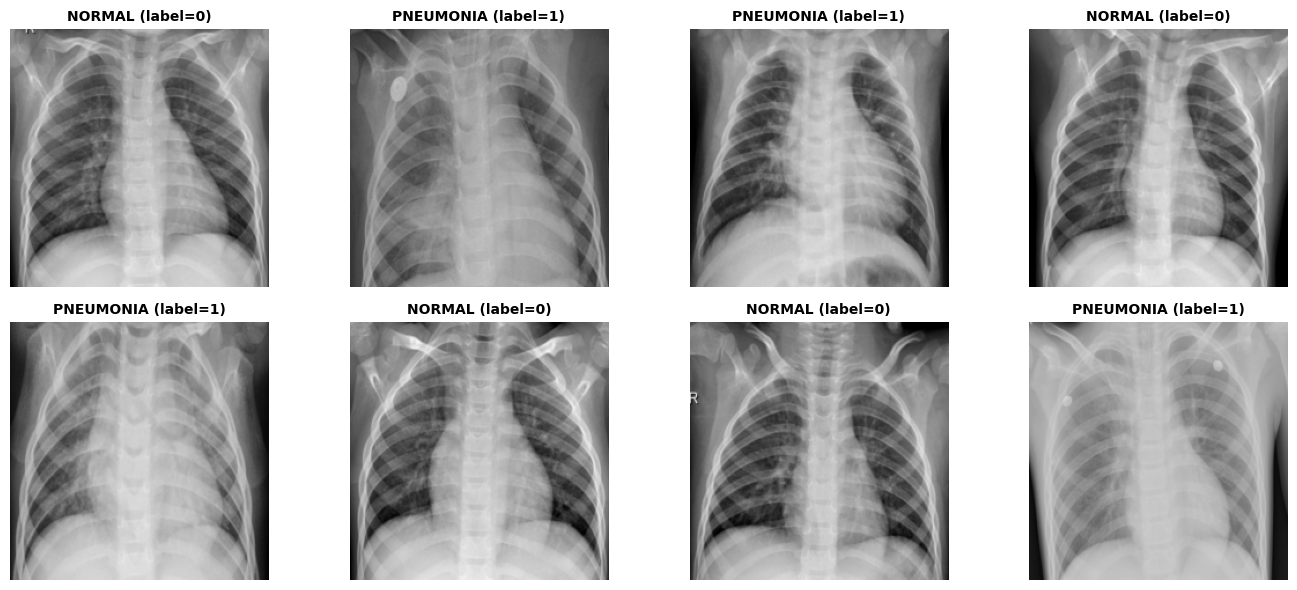

In [28]:
# Visualize a few samples from different classes
if 'batch' in globals() and batch is not None:
    imgs = batch['image']
    labels = batch['label']
    inv_norm = T.Normalize(mean=[-m/s for m,s in zip(IMAGENET_MEAN, IMAGENET_STD)], std=[1/s for s in IMAGENET_STD])
    fig, axs = plt.subplots(2, 4, figsize=(14, 6))
    for i, ax in enumerate(axs.flatten()):
        if i >= imgs.size(0):
            break
        img = inv_norm(imgs[i]).permute(1, 2, 0).numpy()
        img = np.clip(img, 0, 1)
        ax.imshow(img, cmap='gray')
        label = labels[i].item()
        class_name = CLASS_IDX_TO_NAME.get(label, 'Unknown')
        ax.set_title(f'{class_name} (label={label})', fontsize=10, fontweight='bold')
        ax.axis('off')
    plt.tight_layout()
    plt.show()
else:
    print('No batch to visualize')